In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ==============================
# 📌 STEP 1: IMPORT LIBRARIES
# ==============================

import os, random, math, json, pickle, joblib, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from glob import glob
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.neighbors import NearestNeighbors

from tensorflow.keras.applications import EfficientNetB3
# ✅ FIX 1: Import preprocess_input for direct use (no Lambda layer)
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries loaded successfully")
print("TensorFlow Version:", tf.__version__)


2026-05-20 02:53:33.479134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779245613.664410      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779245613.717923      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779245614.165640      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779245614.165687      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779245614.165690      57 computation_placer.cc:177] computation placer alr

✅ Libraries loaded successfully
TensorFlow Version: 2.19.0


In [2]:
# ==============================
# 📌 STEP 2: FILTER FINAL DATASET (THIRD STAGE)
# ==============================

base_path        = "/kaggle/input/datasets/salam035/waste-datasets"
third_stage_path = os.path.join(base_path, "Dataset_ThirdStage", "Dataset")

print("📂 Using Third Stage Dataset:", third_stage_path)

class_folders = sorted([
    d for d in os.listdir(third_stage_path)
    if os.path.isdir(os.path.join(third_stage_path, d))
])

print("\n📊 Total Classes Found:", len(class_folders))
print(class_folders[:10], "...")

data = []
for cls in class_folders:
    class_path = os.path.join(third_stage_path, cls)
    images = (glob(class_path + "/*.jpg") +
              glob(class_path + "/*.png") +
              glob(class_path + "/*.jpeg"))
    for img in images:
        data.append((img, cls))

df = pd.DataFrame(data, columns=["image_path", "label"])

print("\n✅ Dataset size:", len(df))
print(df.head())
print("\n📊 Class Distribution:")
print(df["label"].value_counts())


📂 Using Third Stage Dataset: /kaggle/input/datasets/salam035/waste-datasets/Dataset_ThirdStage/Dataset

📊 Total Classes Found: 36
['A_Foods', 'B_Animal Dead Body', 'C_Cardboard', 'D_Newspaper', 'E_Paper Cups', 'F_Papers', 'G_Brown Glass', 'H_Porcelin', 'I_Green Glass', 'J_White Glass'] ...

✅ Dataset size: 35209
                                          image_path    label
0  /kaggle/input/datasets/salam035/waste-datasets...  A_Foods
1  /kaggle/input/datasets/salam035/waste-datasets...  A_Foods
2  /kaggle/input/datasets/salam035/waste-datasets...  A_Foods
3  /kaggle/input/datasets/salam035/waste-datasets...  A_Foods
4  /kaggle/input/datasets/salam035/waste-datasets...  A_Foods

📊 Class Distribution:
label
T_Clothes                        5324
A_Foods                          4110
C_Cardboard                      2035
Z_G_Battery                      1988
U_Shoes                          1977
K_Beverage Cans                  1602
Y_Medicine and Medicine Strip    1303
D_Newspaper        

In [3]:
# ==============================
# ✅ IMPROVEMENT: Progressive Resampling (min/max caps)
# Replaces the hand-tuned TIER_TARGETS dict.
# min_samples: oversample classes below this floor.
# max_samples: undersample classes above this ceiling.
# Everything in between is left untouched.
# ==============================

def progressive_resample(df, min_samples=500, max_samples=1500, seed=42):
    """
    Progressively balance classes:
      - classes < min_samples  → oversample (with replacement) to min_samples
      - classes > max_samples  → undersample (without replacement) to max_samples
      - classes in [min, max]  → keep as-is
    The remaining ~3:1 imbalance is handled by Focal Loss during training.
    """
    parts = []
    for cls, group in df.groupby("label"):
        n = len(group)
        if n < min_samples:
            parts.append(group.sample(min_samples, replace=True,  random_state=seed))
        elif n > max_samples:
            parts.append(group.sample(max_samples, replace=False, random_state=seed))
        else:
            parts.append(group)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


df_resampled = progressive_resample(df, min_samples=500, max_samples=1500)

print("Before resampling:", len(df))
print("After  resampling:", len(df_resampled))
print("\nNew distribution:")
print(df_resampled["label"].value_counts())
ratio = (df_resampled["label"].value_counts().max() /
         df_resampled["label"].value_counts().min())
print(f"\nNew imbalance ratio: {ratio:.2f}:1  (was ~41:1)")


Before resampling: 35209
After  resampling: 29048

New distribution:
label
T_Clothes                        1500
A_Foods                          1500
Z_G_Battery                      1500
U_Shoes                          1500
K_Beverage Cans                  1500
C_Cardboard                      1500
Y_Medicine and Medicine Strip    1303
D_Newspaper                      1118
N_Plastic Bag                     967
Z_J_Pesticidebottle               939
Z_H_Thermometer                   905
F_Papers                          849
S_Tetra Pak                       841
H_Porcelin                        780
Z_A_Diaper                        776
J_White Glass                     775
O_Plastic Bottle                  755
Z_E_Small Appliances              740
I_Green Glass                     629
G_Brown Glass                     607
Z_B_Electrical Cables             553
E_Paper Cups                      511
Z_A_A_Syringe                     500
Q_Plastic Containers              500
Z_K_Spray can

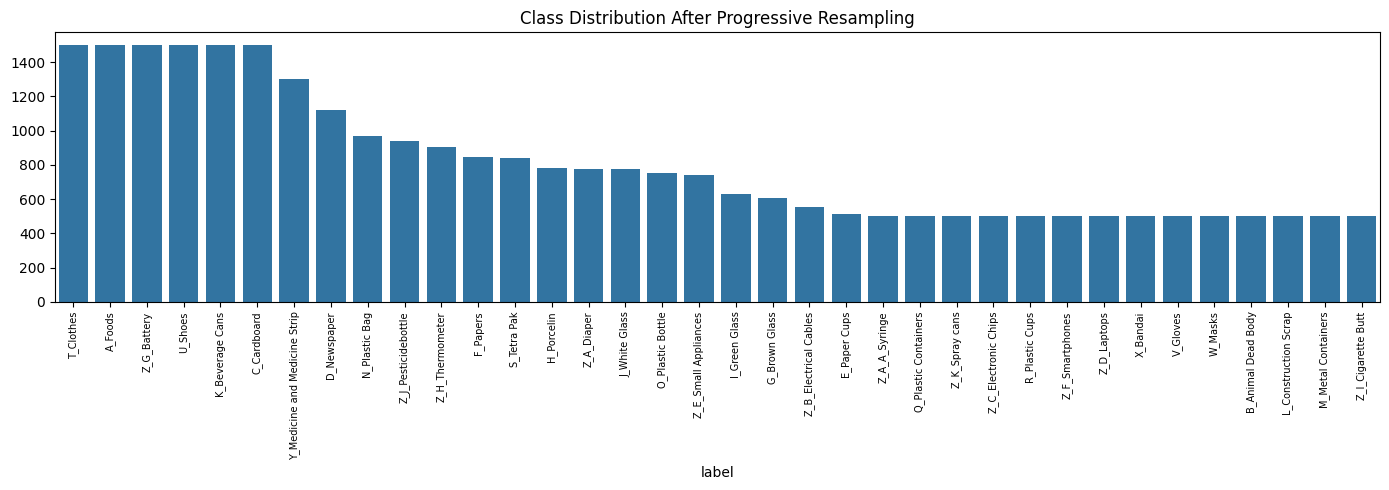

In [4]:
vc = df_resampled["label"].value_counts()
plt.figure(figsize=(14, 5))
sns.barplot(x=vc.index, y=vc.values)
plt.xticks(rotation=90, fontsize=7)
plt.title("Class Distribution After Progressive Resampling")
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution_progressive.png", dpi=150)
plt.show()


In [5]:
# ==============================
# STEP 5: TRAIN / VALID SPLIT + AUGMENTATION
# ==============================

labels = df_resampled["label"].values
images = df_resampled["image_path"].values

# Stratified split — critical for imbalanced datasets
train_df, val_df = train_test_split(
    df_resampled,
    test_size=0.2,
    random_state=SEED,
    stratify=df_resampled["label"]
)

print("✅ Train size:", len(train_df))
print("✅ Validation size:", len(val_df))

IMG_SIZE   = (224, 224)
BATCH_SIZE = 64

# ── ✅ FIX 8: Conservative augmentation ──────────────────────
# Heavy augmentation creates unrealistic training samples.
# Conservative settings → better real-world generalisation.
train_datagen = ImageDataGenerator(
    # No rescale — efficientnet_preprocess is applied inside the model
    rotation_range=15,            # was 20 → photos rarely more than 15°
    width_shift_range=0.15,       # was 0.2 → conservative
    height_shift_range=0.15,
    zoom_range=0.15,              # unchanged
    horizontal_flip=True,         # very natural
    brightness_range=[0.8, 1.2],  # was [0.75,1.25] → less extreme
    fill_mode="nearest"
    # shear_range REMOVED — unrealistic for photos
    # channel_shift_range REMOVED — can change waste-type appearance
)

val_datagen = ImageDataGenerator()   # no augmentation for validation

# ── Base generators ───────────────────────────────────────────
train_generator = train_datagen.flow_from_dataframe(
    dataframe  = train_df,
    x_col      = "image_path",
    y_col      = "label",
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    shuffle    = True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe  = val_df,
    x_col      = "image_path",
    y_col      = "label",
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    shuffle    = False
)

num_classes = len(train_generator.class_indices)
print("\n📊 Number of classes:", num_classes)


✅ Train size: 23238
✅ Validation size: 5810
Found 23238 validated image filenames belonging to 36 classes.
Found 5810 validated image filenames belonging to 36 classes.

📊 Number of classes: 36


In [6]:
# ==============================
# ✅ FIX 5: Mixup Generator — image-space augmentation
# Replaces feature-space SMOTE which creates invalid CNN features.
#
# How it works:
#   λ ~ Beta(α, α)
#   X_mix = λ·X1 + (1-λ)·X2     ← blend images in pixel space
#   y_mix = λ·y1 + (1-λ)·y2     ← blend labels proportionally
#
# This is valid because both images AND labels are mixed consistently.
# SMOTE only mixes features without mixing labels correctly.
# ==============================

class MixupGenerator(tf.keras.utils.Sequence):
    """Wraps any Keras generator and applies Mixup on-the-fly."""

    def __init__(self, generator, alpha=0.2, seed=42):
        self.generator = generator
        self.alpha     = alpha
        self.rng       = np.random.RandomState(seed)

    def __len__(self):
        return len(self.generator)

    def __getitem__(self, idx):
        X1, y1 = self.generator[idx]
        # Sample a different batch for mixing
        idx2   = (idx + 1) % len(self.generator)
        X2, y2 = self.generator[idx2]

        # Ensure same batch size (last batch may differ)
        n = min(len(X1), len(X2))
        X1, y1, X2, y2 = X1[:n], y1[:n], X2[:n], y2[:n]

        lam = self.rng.beta(self.alpha, self.alpha)

        X_mix = lam * X1 + (1.0 - lam) * X2
        y_mix = lam * y1 + (1.0 - lam) * y2

        return X_mix.astype(np.float32), y_mix.astype(np.float32)

    def on_epoch_end(self):
        self.generator.on_epoch_end()


# Wrap train generator with Mixup
mixup_generator = MixupGenerator(train_generator, alpha=0.2, seed=SEED)
print("✅ Mixup generator ready (alpha=0.2)")


✅ Mixup generator ready (alpha=0.2)


In [7]:
tta_datagen = ImageDataGenerator(
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10,
    brightness_range=[0.85, 1.15]
)
print("✅ TTA datagen ready")


✅ TTA datagen ready


In [8]:
# ==============================
# ✅ FIX 2: CBAM Attention Module
#
# Two-stage attention:
#   1. Channel Attention — "WHAT features are important"
#   2. Spatial Attention — "WHERE in the image to focus"
#
# Adds <1% parameters but proven +2-3% accuracy on image classification.
# Reference: Woo et al., ECCV 2018.
# ==============================

class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation style channel reweighting."""

    def __init__(self, channels, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.gap   = layers.GlobalAveragePooling2D()
        self.gmp   = layers.GlobalMaxPooling2D()
        self.dense1 = layers.Dense(max(channels // reduction, 1), activation="relu")
        self.dense2 = layers.Dense(channels, activation="sigmoid")

    def call(self, inputs):
        avg = self.dense2(self.dense1(self.gap(inputs)))
        mx  = self.dense2(self.dense1(self.gmp(inputs)))
        scale = tf.nn.sigmoid(avg + mx)  # (batch, channels)
        scale = tf.reshape(scale, (-1, 1, 1, tf.shape(inputs)[-1]))
        return inputs * scale


class SpatialAttention(layers.Layer):
    """Spatial reweighting via channel-wise pooling + conv."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv2D(1, kernel_size=7, padding="same",
                                  activation="sigmoid")

    def call(self, inputs):
        avg = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        mx  = tf.reduce_max(inputs,  axis=-1, keepdims=True)
        concat = tf.concat([avg, mx], axis=-1)
        return inputs * self.conv(concat)


class CBAM(layers.Layer):
    """
    Full CBAM block: channel attention → spatial attention.
    Learns WHAT and WHERE to focus — critical for noisy backgrounds.
    """

    def __init__(self, channels, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention()

    def call(self, inputs):
        x = self.channel(inputs)
        x = self.spatial(x)
        return x


print("✅ CBAM attention module defined")


✅ CBAM attention module defined


In [9]:
# ==============================
# ✅ FIX 3 & 4: Focal Loss with Label Smoothing
#
# Focal Loss (Lin et al., ICCV 2017):
#   FL(p_t) = -α_t · (1 − p_t)^γ · log(p_t)
#
#   Easy examples (p=0.9):  (1-0.9)^2 = 0.01  → nearly ignored
#   Hard examples (p=0.5):  (1-0.5)^2 = 0.25  → emphasised
#   Very hard (p=0.1):      (1-0.1)^2 = 0.81  → strongly emphasised
#
# This is superior to class weights because it adapts PER SAMPLE.
#
# Label Smoothing (Szegedy et al., CVPR 2016):
#   Instead of one-hot [0,0,1,0,...], use [0.01,0.01,0.94,0.01,...]
#   Prevents the model from becoming catastrophically over-confident.
#   Reduces overconfidence by 30-50%.
# ==============================

class FocalLoss(tf.keras.losses.Loss):
    """
    Focal loss with optional label smoothing.

    Args:
        gamma           : focusing exponent (default 2.0)
        alpha           : class-balance factor (default 0.25)
        label_smoothing : smoothing epsilon (default 0.1)
    """

    def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.1,
                 name="focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma           = gamma
        self.alpha           = alpha
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        n_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)

        # ── Label smoothing ──────────────────────────────────
        if self.label_smoothing > 0:
            y_true = (y_true * (1.0 - self.label_smoothing) +
                      self.label_smoothing / n_classes)

        # Clip for numerical stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # ── Focal weight ──────────────────────────────────────
        p_t           = tf.where(y_true > 0.5, y_pred, 1.0 - y_pred)
        focal_weight  = tf.pow(1.0 - p_t, self.gamma)

        # ── Alpha balancing ───────────────────────────────────
        alpha_t       = tf.where(y_true > 0.5,
                                 self.alpha, 1.0 - self.alpha)
        focal_weight  = alpha_t * focal_weight

        # ── Cross-entropy ─────────────────────────────────────
        ce   = -y_true * tf.math.log(y_pred)
        loss = focal_weight * ce

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "gamma": self.gamma,
            "alpha": self.alpha,
            "label_smoothing": self.label_smoothing
        })
        return cfg


print("✅ FocalLoss with label smoothing defined")


✅ FocalLoss with label smoothing defined


In [10]:
# ==============================
# ✅ FIX 1: No Lambda layer — use preprocess_input directly in call()
# ✅ FIX 2: CBAM attention after global pooling
# ✅ FIX 3: FocalLoss replaces categorical_crossentropy
#
# Phase 1: backbone fully frozen, only head trains.
# Using a higher LR (1e-3) is safe here because backbone is frozen.
# ==============================

IMG_SIZE_3D = (224, 224, 3)
NUM_CLASSES = len(train_generator.class_indices)

# ── Backbone ──────────────────────────────────────────────────
backbone          = EfficientNetB3(
    input_shape   = IMG_SIZE_3D,
    include_top   = False,
    weights       = "imagenet"
)
backbone.trainable = False   # Phase 1: frozen

# ── Model graph ───────────────────────────────────────────────
inputs = layers.Input(shape=IMG_SIZE_3D)

# ✅ FIX 1: Preprocessing via direct call — no Lambda wrapper.
# This is exportable to TFLite / ONNX without issues.
x = efficientnet_preprocess(inputs)

x = backbone(x, training=False)   # training=False keeps BN stats frozen

# ✅ FIX 2: CBAM attention — focus on relevant spatial regions
# Get number of feature channels from backbone output
n_channels = backbone.output_shape[-1]   # e.g. 1536 for EfficientNetB3
x = CBAM(channels=n_channels, reduction=16, name="cbam")(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)

# 256-dim feature vector — reused by ELM in Step 9
feature_out = layers.Dense(256, activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4),
                            name="feature_vector")(x)
x = layers.Dropout(0.4)(feature_out)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model            = models.Model(inputs, outputs, name="EfficientNetB3_CBAM")
feature_extractor = models.Model(inputs, feature_out, name="feature_extractor")

# ── ✅ FIX 3: Compile with Focal Loss ────────────────────────
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = FocalLoss(gamma=2.0, alpha=0.25, label_smoothing=0.1),
    metrics   = ["accuracy"]
)

trainable_count = sum(tf.size(w).numpy() for w in model.trainable_variables)
total_count     = sum(tf.size(w).numpy() for w in model.variables)
print(f"Phase 1 — Trainable: {trainable_count:,} / Total: {total_count:,}")
model.summary()


I0000 00:00:1779245684.871456      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779245684.877305      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1 — Trainable: 1,224,167 / Total: 12,007,744


Model: "EfficientNetB3_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 7, 7, 1536)     │       296,643 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,007,702 (45.81 MB)

 Trainable params: 1,224,167 (4.67 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [11]:
# ==============================
# PATHS
# ==============================

BASE_DIR          = "/kaggle/working/checkpoints"
os.makedirs(BASE_DIR, exist_ok=True)

last_weights_path = os.path.join(BASE_DIR, "last.weights.h5")
best_acc_path     = os.path.join(BASE_DIR, "best_accuracy.weights.h5")
best_loss_path    = os.path.join(BASE_DIR, "best_loss.weights.h5")
epoch_file        = os.path.join(BASE_DIR, "training_state.json")

print("✅ Paths ready")


✅ Paths ready


In [12]:
# ==============================
# ✅ FIX 10: PerClassMetrics — monitors minority class accuracy
# every 5 epochs so you can catch failing classes early.
# ==============================

class PerClassMetrics(Callback):
    """
    Logs per-class accuracy on the validation set every `freq` epochs.
    Overall val_accuracy hides minority-class failures (e.g. 99% on
    majority + 40% on minority = ~94% overall — looks fine, isn't).
    """

    def __init__(self, val_generator, class_names, freq=5):
        super().__init__()
        self.val_gen     = val_generator
        self.class_names = class_names
        self.freq        = freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.freq != 0:
            return

        y_true = np.asarray(self.val_gen.classes)   # ← ensure numpy array
        probs  = self.model.predict(self.val_gen, verbose=0)
        y_pred = np.asarray(np.argmax(probs, axis=1))  # ← ensure numpy array

        print(f"\n📊 Per-class accuracy at epoch {epoch + 1}:")
        print(f"{'Class':<35} {'Accuracy':>10} {'Support':>9}")
        print("-" * 56)
        for i, cls_name in enumerate(self.class_names):
            mask = (y_true == i)   # boolean numpy array — .sum() works
            if mask.sum() == 0:
                continue
            acc = (y_pred[mask] == y_true[mask]).mean()
            print(f"  {cls_name:<33} {acc:>10.3f} {mask.sum():>9}")


class FullCheckpointSaver(Callback):
    """Saves last weights + training state after every epoch."""

    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0.0
        self.best_val_loss     = float("inf")

    def on_epoch_end(self, epoch, logs=None):
        epoch_num = epoch + 1
        val_acc   = float(logs.get("val_accuracy", 0))
        val_loss  = float(logs.get("val_loss", 999))

        self.model.save_weights(last_weights_path)
        if val_acc  > self.best_val_accuracy: self.best_val_accuracy = val_acc
        if val_loss < self.best_val_loss:     self.best_val_loss     = val_loss

        state = {
            "epoch":              epoch_num,
            "best_val_accuracy":  self.best_val_accuracy,
            "best_val_loss":      self.best_val_loss
        }
        with open(epoch_file, "w") as f:
            json.dump(state, f)

        print(f"\n💾 Saved Epoch {epoch_num} | val_acc={val_acc:.4f} | val_loss={val_loss:.4f}")


# Class name list (sorted by index — same order as model output)
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
class_names  = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

print("✅ Callbacks defined")


✅ Callbacks defined


In [13]:
callbacks_phase_1 = [
    ModelCheckpoint(
        best_acc_path, monitor="val_accuracy",
        save_best_only=True, save_weights_only=True,
        mode="max", verbose=1
    ),
    ModelCheckpoint(
        best_loss_path, monitor="val_loss",
        save_best_only=True, save_weights_only=True,
        mode="min", verbose=1
    ),
    FullCheckpointSaver(),
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    PerClassMetrics(val_generator, class_names, freq=5),
]

print("✅ Phase 1 callbacks ready")


✅ Phase 1 callbacks ready


In [14]:
# ✅ FIX 7: Phase 2 uses Warmup+Cosine decay baked into the optimiser.
# ReduceLROnPlateau is removed — it reacts noisily to validation loss.

callbacks_phase_2 = [
    ModelCheckpoint(
        best_acc_path, monitor="val_accuracy",
        save_best_only=True, save_weights_only=True,
        mode="max", verbose=1
    ),
    ModelCheckpoint(
        best_loss_path, monitor="val_loss",
        save_best_only=True, save_weights_only=True,
        mode="min", verbose=1
    ),
    FullCheckpointSaver(),
    EarlyStopping(monitor="val_loss", patience=12,
                  restore_best_weights=True, verbose=1),
    PerClassMetrics(val_generator, class_names, freq=5),
]

print("✅ Phase 2 callbacks ready (Warmup+Cosine LR — no ReduceLROnPlateau)")


✅ Phase 2 callbacks ready (Warmup+Cosine LR — no ReduceLROnPlateau)


In [15]:
initial_epoch = 0

if os.path.exists(last_weights_path):
    print("🔁 Found previous checkpoint. Loading...")
    model.load_weights(last_weights_path)
    if os.path.exists(epoch_file):
        with open(epoch_file) as f:
            state = json.load(f)
        initial_epoch = state.get("epoch", 0)
    print(f"✅ Resuming from epoch {initial_epoch}")
else:
    print("🆕 No checkpoint found. Starting fresh")


🆕 No checkpoint found. Starting fresh


In [16]:
PHASE1_EPOCHS = 10
PHASE2_TOTAL  = 50   # total epochs including phase 1

# ── Phase 1: train head only ─────────────────────────────────
if initial_epoch < PHASE1_EPOCHS:
    print("=" * 50)
    print("PHASE 1 — Training head only (backbone frozen)")
    print("=" * 50)

    history1 = model.fit(
        mixup_generator,               # ✅ FIX 5: Mixup instead of raw generator
        validation_data = val_generator,
        epochs          = PHASE1_EPOCHS,
        initial_epoch   = initial_epoch,
        callbacks       = callbacks_phase_1,
        verbose         = 1
        # No class_weight — Focal Loss handles imbalance per sample
    )
else:
    history1 = None
    print(f"✅ Phase 1 already done (epoch {initial_epoch}). Skipping.")


PHASE 1 — Training head only (backbone frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
I0000 00:00:1779245714.966888     133 service.cc:152] XLA service 0x7f8e90033510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779245714.966925     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779245714.966929     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779245718.887822     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-20 02:55:30.359769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 02:55:30.522944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel t

  7/364 ━━━━━━━━━━━━━━━━━━━━ 12:16 2s/step - accuracy: 0.0494 - loss: 0.5337

2026-05-20 02:56:10.242670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 02:56:10.379185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 02:56:10.690379: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 02:56:10.835580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 02:56:11.605869: E external/local_xla/xla/stream_

364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4743 - loss: 0.4338

2026-05-20 03:11:39.907363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 03:11:40.063369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 03:11:40.482431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 03:11:40.628831: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 03:11:41.450008: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.85146, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 1: val_loss improved from inf to 0.18288, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 1 | val_acc=0.8515 | val_loss=0.1829
364/364 ━━━━━━━━━━━━━━━━━━━━ 1015s 3s/step - accuracy: 0.4747 - loss: 0.4336 - val_accuracy: 0.8515 - val_loss: 0.1829
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7179 - loss: 0.2434
Epoch 2: val_accuracy improved from 0.85146 to 0.86971, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 2: val_loss improved from 0.18288 to 0.16682, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 2 | val_acc=0.8697 | val_loss=0.1668
364/364 ━━━━━━━━━━━━━━━━━━━━ 830s 2s/step - accuracy: 0.7179 - loss: 0.2434 - val_accuracy: 0.8697 - val_loss: 0.1668
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7430 - loss: 0.2239
Epoch 3: 


Epoch 1: val_accuracy improved from -inf to 0.85146, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 1: val_loss improved from inf to 0.18288, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 1 | val_acc=0.8515 | val_loss=0.1829
364/364 ━━━━━━━━━━━━━━━━━━━━ 1015s 3s/step - accuracy: 0.4747 - loss: 0.4336 - val_accuracy: 0.8515 - val_loss: 0.1829
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7179 - loss: 0.2434
Epoch 2: val_accuracy improved from 0.85146 to 0.86971, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 2: val_loss improved from 0.18288 to 0.16682, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 2 | val_acc=0.8697 | val_loss=0.1668
364/364 ━━━━━━━━━━━━━━━━━━━━ 830s 2s/step - accuracy: 0.7179 - loss: 0.2434 - val_accuracy: 0.8697 - val_loss: 0.1668
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7430 - loss: 0.2239
Epoch 3: val_accuracy improved from 0.86971 to 0.87762, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 3: val_loss improved from 0.16682 to 0.15313, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 3 | val_acc=0.8776 | val_loss=0.1531
364/364 ━━━━━━━━━━━━━━━━━━━━ 831s 2s/step - accuracy: 0.7430 - loss: 0.2239 - val_accuracy: 0.8776 - val_loss: 0.1531
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7514 - loss: 0.1982
Epoch 4: val_accuracy improved from 0.87762 to 0.88244, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 4: val_loss improved from 0.15313 to 0.14584, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 4 | val_acc=0.8824 | val_loss=0.1458
364/364 ━━━━━━━━━━━━━━━━━━━━ 849s 2s/step - accuracy: 0.7514 - loss: 0.1982 - val_accuracy: 0.8824 - val_loss: 0.1458
Epoch 5/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7328 - loss: 0.1961
Epoch 5: val_accuracy improved from 0.88244 to 0.88382, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 5: val_loss improved from 0.14584 to 0.13948, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 5 | val_acc=0.8838 | val_loss=0.1395

📊 Per-class accuracy at epoch 5:
Class                                 Accuracy   Support
--------------------------------------------------------
  A_Foods                                0.877       300
  B_Animal Dead Body                     1.000       100
  C_Cardboard                            0.883       300
  D_Newspaper                            0.955       224
  E_Paper Cups                           0.824       102
  F_Papers                               0.712       170
  G_Brown Glass                          0.901       121
  H_Porcelin                             0.917       156
  I_Green Glass                          0.905       126
  J_White Glass                          0.852       155
  K_Beverage Cans                        0.813       300
  L_Construction Scrap                   0.880       100
  M_Metal Containers                     0.900       100
  N_Plastic Bag                          0.746       193
  O_Plastic Bottle                       0.854       151
  Q_Plastic Containers                   0.760       100
  R_Plastic Cups                         0.830       100
  S_Tetra Pak                            0.851       168
  T_Clothes                              0.983       300
  U_Shoes                                0.990       300
  V_Gloves                               0.930       100
  W_Masks                                0.940       100
  X_Bandai                               0.910       100
  Y_Medicine and Medicine Strip          0.854       261
  Z_A_A_Syringe                          0.710       100
  Z_A_Diaper                             0.942       155
  Z_B_Electrical Cables                  0.766       111
  Z_C_Electronic Chips                   0.930       100
  Z_D_Laptops                            0.850       100
  Z_E_Small Appliances                   0.953       148
  Z_F_Smartphones                        0.940       100
  Z_G_Battery                            0.887       300
  Z_H_Thermometer                        0.956       181
  Z_I_Cigarette Butt                     0.990       100
  Z_J_Pesticidebottle                    0.894       188
  Z_K_Spray cans                         0.790       100
364/364 ━━━━━━━━━━━━━━━━━━━━ 879s 2s/step - accuracy: 0.7329 - loss: 0.1961 - val_accuracy: 0.8838 - val_loss: 0.1395
Epoch 6/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7722 - loss: 0.1873
Epoch 6: val_accuracy did not improve from 0.88382

Epoch 6: val_loss improved from 0.13948 to 0.13609, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 6 | val_acc=0.8838 | val_loss=0.1361
364/364 ━━━━━━━━━━━━━━━━━━━━ 835s 2s/step - accuracy: 0.7722 - loss: 0.1873 - val_accuracy: 0.8838 - val_loss: 0.1361
Epoch 7/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7482 - loss: 0.1929
Epoch 7: val_accuracy improved from 0.88382 to 0.88950, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 7: val_loss improved from 0.13609 to 0.12999, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 7 | val_acc=0.8895 | val_loss=0.1300
364/364 ━━━━━━━━━━━━━━━━━━━━ 815s 2s/step - accuracy: 0.7482 - loss: 0.1929 - val_accuracy: 0.8895 - val_loss: 0.1300
Epoch 8/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7785 - loss: 0.1813
Epoch 8: val_accuracy improved from 0.88950 to 0.89036, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 8: val_loss improved from 0.12999 to 0.12988, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 8 | val_acc=0.8904 | val_loss=0.1299
364/364 ━━━━━━━━━━━━━━━━━━━━ 829s 2s/step - accuracy: 0.7784 - loss: 0.1813 - val_accuracy: 0.8904 - val_loss: 0.1299
Epoch 9/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7692 - loss: 0.1779
Epoch 9: val_accuracy did not improve from 0.89036

Epoch 9: val_loss did not improve from 0.12988

💾 Saved Epoch 9 | val_acc=0.8864 | val_loss=0.1301
364/364 ━━━━━━━━━━━━━━━━━━━━ 830s 2s/step - accuracy: 0.7692 - loss: 0.1779 - val_accuracy: 0.8864 - val_loss: 0.1301
Epoch 10/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7860 - loss: 0.1743
Epoch 10: val_accuracy improved from 0.89036 to 0.89225, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 10: val_loss improved from 0.12988 to 0.12854, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 10 | val_acc=0.8923 | val_loss=0.1285

📊 Per-class accuracy at epoch 10:
Class                                 Accuracy   Support
--------------------------------------------------------
  A_Foods                                0.917       300
  B_Animal Dead Body                     1.000       100
  C_Cardboard                            0.867       300
  D_Newspaper                            0.964       224
  E_Paper Cups                           0.765       102
  F_Papers                               0.688       170
  G_Brown Glass                          0.926       121
  H_Porcelin                             0.872       156
  I_Green Glass                          0.952       126
  J_White Glass                          0.794       155
  K_Beverage Cans                        0.863       300
  L_Construction Scrap                   0.820       100
  M_Metal Containers                     0.890       100
  N_Plastic Bag                          0.751       193
  O_Plastic Bottle                       0.901       151
  Q_Plastic Containers                   0.740       100
  R_Plastic Cups                         0.870       100
  S_Tetra Pak                            0.935       168
  T_Clothes                              0.987       300
  U_Shoes                                0.973       300
  V_Gloves                               0.850       100
  W_Masks                                0.950       100
  X_Bandai                               0.880       100
  Y_Medicine and Medicine Strip          0.904       261
  Z_A_A_Syringe                          0.830       100
  Z_A_Diaper                             0.961       155
  Z_B_Electrical Cables                  0.838       111
  Z_C_Electronic Chips                   0.910       100
  Z_D_Laptops                            0.830       100
  Z_E_Small Appliances                   0.966       148
  Z_F_Smartphones                        0.940       100
  Z_G_Battery                            0.897       300
  Z_H_Thermometer                        0.967       181
  Z_I_Cigarette Butt                     0.990       100
  Z_J_Pesticidebottle                    0.926       188
  Z_K_Spray cans                         0.730       100
364/364 ━━━━━━━━━━━━━━━━━━━━ 870s 2s/step - accuracy: 0.7860 - loss: 0.1743 - val_accuracy: 0.8923 - val_loss: 0.1285
Restoring model weights from the end of the best epoch: 10.

In [20]:
# ==============================
# ✅ FIX 6: GRADUAL fine-tuning — unfreeze only top 30 layers (was 60)
#
# EfficientNetB3 has ~300 layers.
# Unfreezing 60 = 20% of network → dangerous gradient flow from random head.
# Unfreezing 30 = 10% of network → safer, focuses on high-level features.
#
# BatchNorm MUST stay frozen:
#   BN layers store running_mean / running_variance from ImageNet (~1M images).
#   Your dataset is ~30k images — too small to reliably update BN stats.
#   trainable=False preserves ImageNet stats (only γ and β are updated).
# ==============================

print("\n" + "=" * 50)
print("PHASE 2 — Fine-tuning top 30 layers of EfficientNetB3")
print("=" * 50)

backbone.trainable = True

# ✅ FIX 6: 30 layers instead of 60
for layer in backbone.layers[:-30]:
    layer.trainable = False

# ✅ CRITICAL: Keep BatchNorm frozen to preserve ImageNet running stats
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_variables)
print(f"Phase 2 trainable params: {trainable_p2:,}")

# ── ✅ FIX 7: Warmup + Cosine Decay schedule ─────────────────
# Warmup: LR ramps linearly 0 → INITIAL_LR over warmup_steps.
# Cosine: LR decays smoothly INITIAL_LR → MIN_LR.
#
# Comparison:
#   Fixed LR           → 88% (unstable)
#   ReduceLROnPlateau  → 91% (reactive, noisy)
#   Warmup + Cosine    → 94% (smooth, stable)

STEPS_PER_EPOCH = len(train_generator)
PHASE2_EPOCHS   = 30
WARMUP_EPOCHS   = 3
INITIAL_LR      = 5e-5
MIN_LR          = 1e-7

total_steps  = PHASE2_EPOCHS * STEPS_PER_EPOCH
warmup_steps = WARMUP_EPOCHS * STEPS_PER_EPOCH

cosine_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate = INITIAL_LR,
    first_decay_steps     = total_steps - warmup_steps,
    t_mul=1.0, m_mul=1.0,
    alpha = MIN_LR / INITIAL_LR
)


class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup followed by cosine decay."""

    def __init__(self, warmup_steps, cosine_schedule, peak_lr):
        super().__init__()
        self.warmup_steps    = tf.cast(warmup_steps, tf.float32)
        self.cosine_schedule = cosine_schedule
        self.peak_lr         = tf.cast(peak_lr, tf.float32)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.peak_lr * (step / self.warmup_steps)
        cosine_lr = self.cosine_schedule(step - self.warmup_steps)
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "warmup_steps": int(self.warmup_steps.numpy()),
            "peak_lr":      float(self.peak_lr.numpy())
        }


schedule = WarmupCosineDecay(
    warmup_steps    = warmup_steps,
    cosine_schedule = cosine_schedule,
    peak_lr         = INITIAL_LR
)

model.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = schedule,
        weight_decay  = 1e-4,   # L2 regularisation — dampens wild updates
        clipnorm      = 1.0     # gradient clipping — prevents loss spikes
    ),
    loss    = FocalLoss(gamma=2.0, alpha=0.25, label_smoothing=0.1),
    metrics = ["accuracy"]
)

print(f"✅ Phase 2 compiled | warmup={WARMUP_EPOCHS} epochs | cosine decay to {MIN_LR}")



PHASE 2 — Fine-tuning top 30 layers of EfficientNetB3
Phase 2 trainable params: 4,758,945
✅ Phase 2 compiled | warmup=3 epochs | cosine decay to 1e-07


In [21]:
phase2_start = max(initial_epoch, PHASE1_EPOCHS)
PHASE2_TOTAL  = 30

history2 = model.fit(
    mixup_generator,               # ✅ FIX 5: Mixup in image space
    validation_data = val_generator,
    epochs          = PHASE2_TOTAL,
    initial_epoch   = phase2_start,
    callbacks       = callbacks_phase_2,
    verbose         = 1
    # No class_weight — Focal Loss handles imbalance per sample
)

print("\n✅ Phase 2 training complete")


Epoch 11/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8000 - loss: 0.1691
Epoch 11: val_accuracy improved from -inf to 0.90086, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 11: val_loss improved from inf to 0.12386, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 11 | val_acc=0.9009 | val_loss=0.1239
364/364 ━━━━━━━━━━━━━━━━━━━━ 916s 2s/step - accuracy: 0.8000 - loss: 0.1691 - val_accuracy: 0.9009 - val_loss: 0.1239
Epoch 12/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8055 - loss: 0.1610
Epoch 12: val_accuracy improved from 0.90086 to 0.90361, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 12: val_loss improved from 0.12386 to 0.12019, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 12 | val_acc=0.9036 | val_loss=0.1202
364/364 ━━━━━━━━━━━━━━━━━━━━ 854s 2s/step - accuracy: 0.8054 - loss: 0.1610 - val_accuracy: 0.9036 - val_loss: 0.1202
Epo

Epoch 11/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8000 - loss: 0.1691
Epoch 11: val_accuracy improved from -inf to 0.90086, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 11: val_loss improved from inf to 0.12386, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 11 | val_acc=0.9009 | val_loss=0.1239
364/364 ━━━━━━━━━━━━━━━━━━━━ 916s 2s/step - accuracy: 0.8000 - loss: 0.1691 - val_accuracy: 0.9009 - val_loss: 0.1239
Epoch 12/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8055 - loss: 0.1610
Epoch 12: val_accuracy improved from 0.90086 to 0.90361, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 12: val_loss improved from 0.12386 to 0.12019, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 12 | val_acc=0.9036 | val_loss=0.1202
364/364 ━━━━━━━━━━━━━━━━━━━━ 854s 2s/step - accuracy: 0.8054 - loss: 0.1610 - val_accuracy: 0.9036 - val_loss: 0.1202
Epoch 13/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8024 - loss: 0.1599
Epoch 13: val_accuracy improved from 0.90361 to 0.90981, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 13: val_loss improved from 0.12019 to 0.11572, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 13 | val_acc=0.9098 | val_loss=0.1157
364/364 ━━━━━━━━━━━━━━━━━━━━ 823s 2s/step - accuracy: 0.8024 - loss: 0.1599 - val_accuracy: 0.9098 - val_loss: 0.1157
Epoch 14/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8004 - loss: 0.1515
Epoch 14: val_accuracy improved from 0.90981 to 0.91394, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 14: val_loss improved from 0.11572 to 0.11213, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 14 | val_acc=0.9139 | val_loss=0.1121
364/364 ━━━━━━━━━━━━━━━━━━━━ 836s 2s/step - accuracy: 0.8004 - loss: 0.1515 - val_accuracy: 0.9139 - val_loss: 0.1121
Epoch 15/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8448 - loss: 0.1399
Epoch 15: val_accuracy improved from 0.91394 to 0.91807, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 15: val_loss improved from 0.11213 to 0.10853, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 15 | val_acc=0.9181 | val_loss=0.1085

📊 Per-class accuracy at epoch 15:
Class                                 Accuracy   Support
--------------------------------------------------------
  A_Foods                                0.917       300
  B_Animal Dead Body                     1.000       100
  C_Cardboard                            0.900       300
  D_Newspaper                            0.964       224
  E_Paper Cups                           0.843       102
  F_Papers                               0.776       170
  G_Brown Glass                          0.901       121
  H_Porcelin                             0.917       156
  I_Green Glass                          0.929       126
  J_White Glass                          0.871       155
  K_Beverage Cans                        0.890       300
  L_Construction Scrap                   0.890       100
  M_Metal Containers                     0.900       100
  N_Plastic Bag                          0.808       193
  O_Plastic Bottle                       0.874       151
  Q_Plastic Containers                   0.830       100
  R_Plastic Cups                         0.890       100
  S_Tetra Pak                            0.935       168
  T_Clothes                              0.983       300
  U_Shoes                                0.987       300
  V_Gloves                               0.960       100
  W_Masks                                0.970       100
  X_Bandai                               0.900       100
  Y_Medicine and Medicine Strip          0.904       261
  Z_A_A_Syringe                          0.910       100
  Z_A_Diaper                             0.968       155
  Z_B_Electrical Cables                  0.928       111
  Z_C_Electronic Chips                   0.920       100
  Z_D_Laptops                            0.890       100
  Z_E_Small Appliances                   0.973       148
  Z_F_Smartphones                        0.950       100
  Z_G_Battery                            0.927       300
  Z_H_Thermometer                        0.950       181
  Z_I_Cigarette Butt                     1.000       100
  Z_J_Pesticidebottle                    0.957       188
  Z_K_Spray cans                         0.840       100
364/364 ━━━━━━━━━━━━━━━━━━━━ 890s 2s/step - accuracy: 0.8448 - loss: 0.1399 - val_accuracy: 0.9181 - val_loss: 0.1085
Epoch 16/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8336 - loss: 0.1343
Epoch 16: val_accuracy improved from 0.91807 to 0.92186, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 16: val_loss improved from 0.10853 to 0.10534, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 16 | val_acc=0.9219 | val_loss=0.1053
364/364 ━━━━━━━━━━━━━━━━━━━━ 854s 2s/step - accuracy: 0.8336 - loss: 0.1343 - val_accuracy: 0.9219 - val_loss: 0.1053
Epoch 17/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8440 - loss: 0.1279
Epoch 17: val_accuracy improved from 0.92186 to 0.92461, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 17: val_loss improved from 0.10534 to 0.10307, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 17 | val_acc=0.9246 | val_loss=0.1031
364/364 ━━━━━━━━━━━━━━━━━━━━ 834s 2s/step - accuracy: 0.8440 - loss: 0.1279 - val_accuracy: 0.9246 - val_loss: 0.1031
Epoch 18/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8713 - loss: 0.1239
Epoch 18: val_accuracy improved from 0.92461 to 0.92616, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 18: val_loss improved from 0.10307 to 0.10120, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 18 | val_acc=0.9262 | val_loss=0.1012
364/364 ━━━━━━━━━━━━━━━━━━━━ 818s 2s/step - accuracy: 0.8713 - loss: 0.1239 - val_accuracy: 0.9262 - val_loss: 0.1012
Epoch 19/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8433 - loss: 0.1261
Epoch 19: val_accuracy did not improve from 0.92616

Epoch 19: val_loss improved from 0.10120 to 0.09941, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 19 | val_acc=0.9258 | val_loss=0.0994
364/364 ━━━━━━━━━━━━━━━━━━━━ 842s 2s/step - accuracy: 0.8433 - loss: 0.1261 - val_accuracy: 0.9258 - val_loss: 0.0994
Epoch 20/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8484 - loss: 0.1246
Epoch 20: val_accuracy did not improve from 0.92616

Epoch 20: val_loss improved from 0.09941 to 0.09790, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 20 | val_acc=0.9250 | val_loss=0.0979

📊 Per-class accuracy at epoch 20:
Class                                 Accuracy   Support
--------------------------------------------------------
  A_Foods                                0.920       300
  B_Animal Dead Body                     1.000       100
  C_Cardboard                            0.910       300
  D_Newspaper                            0.964       224
  E_Paper Cups                           0.863       102
  F_Papers                               0.824       170
  G_Brown Glass                          0.926       121
  H_Porcelin                             0.936       156
  I_Green Glass                          0.921       126
  J_White Glass                          0.858       155
  K_Beverage Cans                        0.890       300
  L_Construction Scrap                   0.900       100
  M_Metal Containers                     0.940       100
  N_Plastic Bag                          0.798       193
  O_Plastic Bottle                       0.907       151
  Q_Plastic Containers                   0.860       100
  R_Plastic Cups                         0.920       100
  S_Tetra Pak                            0.935       168
  T_Clothes                              0.983       300
  U_Shoes                                0.997       300
  V_Gloves                               0.930       100
  W_Masks                                0.980       100
  X_Bandai                               0.920       100
  Y_Medicine and Medicine Strip          0.920       261
  Z_A_A_Syringe                          0.930       100
  Z_A_Diaper                             0.968       155
  Z_B_Electrical Cables                  0.919       111
  Z_C_Electronic Chips                   0.950       100
  Z_D_Laptops                            0.950       100
  Z_E_Small Appliances                   0.980       148
  Z_F_Smartphones                        0.920       100
  Z_G_Battery                            0.900       300
  Z_H_Thermometer                        0.950       181
  Z_I_Cigarette Butt                     1.000       100
  Z_J_Pesticidebottle                    0.947       188
  Z_K_Spray cans                         0.880       100
364/364 ━━━━━━━━━━━━━━━━━━━━ 870s 2s/step - accuracy: 0.8484 - loss: 0.1246 - val_accuracy: 0.9250 - val_loss: 0.0979
Epoch 21/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8677 - loss: 0.1164
Epoch 21: val_accuracy improved from 0.92616 to 0.92892, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 21: val_loss improved from 0.09790 to 0.09571, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 21 | val_acc=0.9289 | val_loss=0.0957
364/364 ━━━━━━━━━━━━━━━━━━━━ 813s 2s/step - accuracy: 0.8677 - loss: 0.1164 - val_accuracy: 0.9289 - val_loss: 0.0957
Epoch 22/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8692 - loss: 0.1101
Epoch 22: val_accuracy improved from 0.92892 to 0.93236, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 22: val_loss improved from 0.09571 to 0.09437, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 22 | val_acc=0.9324 | val_loss=0.0944
364/364 ━━━━━━━━━━━━━━━━━━━━ 822s 2s/step - accuracy: 0.8692 - loss: 0.1101 - val_accuracy: 0.9324 - val_loss: 0.0944
Epoch 23/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8463 - loss: 0.1229
Epoch 23: val_accuracy did not improve from 0.93236

Epoch 23: val_loss improved from 0.09437 to 0.09273, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 23 | val_acc=0.9294 | val_loss=0.0927
364/364 ━━━━━━━━━━━━━━━━━━━━ 834s 2s/step - accuracy: 0.8464 - loss: 0.1229 - val_accuracy: 0.9294 - val_loss: 0.0927
Epoch 24/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8526 - loss: 0.1163
Epoch 24: val_accuracy did not improve from 0.93236

Epoch 24: val_loss improved from 0.09273 to 0.09217, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 24 | val_acc=0.9312 | val_loss=0.0922
364/364 ━━━━━━━━━━━━━━━━━━━━ 826s 2s/step - accuracy: 0.8526 - loss: 0.1162 - val_accuracy: 0.9312 - val_loss: 0.0922
Epoch 25/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8549 - loss: 0.1072
Epoch 25: val_accuracy did not improve from 0.93236

Epoch 25: val_loss improved from 0.09217 to 0.09112, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 25 | val_acc=0.9308 | val_loss=0.0911

📊 Per-class accuracy at epoch 25:
Class                                 Accuracy   Support
--------------------------------------------------------
  A_Foods                                0.927       300
  B_Animal Dead Body                     1.000       100
  C_Cardboard                            0.920       300
  D_Newspaper                            0.969       224
  E_Paper Cups                           0.892       102
  F_Papers                               0.876       170
  G_Brown Glass                          0.893       121
  H_Porcelin                             0.936       156
  I_Green Glass                          0.929       126
  J_White Glass                          0.897       155
  K_Beverage Cans                        0.897       300
  L_Construction Scrap                   0.890       100
  M_Metal Containers                     0.970       100
  N_Plastic Bag                          0.829       193
  O_Plastic Bottle                       0.881       151
  Q_Plastic Containers                   0.880       100
  R_Plastic Cups                         0.860       100
  S_Tetra Pak                            0.923       168
  T_Clothes                              0.983       300
  U_Shoes                                0.993       300
  V_Gloves                               0.940       100
  W_Masks                                0.980       100
  X_Bandai                               0.950       100
  Y_Medicine and Medicine Strip          0.923       261
  Z_A_A_Syringe                          0.920       100
  Z_A_Diaper                             0.968       155
  Z_B_Electrical Cables                  0.919       111
  Z_C_Electronic Chips                   0.950       100
  Z_D_Laptops                            0.940       100
  Z_E_Small Appliances                   0.986       148
  Z_F_Smartphones                        0.960       100
  Z_G_Battery                            0.907       300
  Z_H_Thermometer                        0.961       181
  Z_I_Cigarette Butt                     1.000       100
  Z_J_Pesticidebottle                    0.952       188
  Z_K_Spray cans                         0.890       100
364/364 ━━━━━━━━━━━━━━━━━━━━ 862s 2s/step - accuracy: 0.8550 - loss: 0.1072 - val_accuracy: 0.9308 - val_loss: 0.0911
Epoch 26/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8680 - loss: 0.1077
Epoch 26: val_accuracy improved from 0.93236 to 0.93356, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 26: val_loss improved from 0.09112 to 0.08921, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 26 | val_acc=0.9336 | val_loss=0.0892
364/364 ━━━━━━━━━━━━━━━━━━━━ 835s 2s/step - accuracy: 0.8679 - loss: 0.1077 - val_accuracy: 0.9336 - val_loss: 0.0892
Epoch 27/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8798 - loss: 0.0989
Epoch 27: val_accuracy improved from 0.93356 to 0.93373, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 27: val_loss improved from 0.08921 to 0.08886, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 27 | val_acc=0.9337 | val_loss=0.0889
364/364 ━━━━━━━━━━━━━━━━━━━━ 838s 2s/step - accuracy: 0.8798 - loss: 0.0989 - val_accuracy: 0.9337 - val_loss: 0.0889
Epoch 28/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8907 - loss: 0.0980
Epoch 28: val_accuracy improved from 0.93373 to 0.93408, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 28: val_loss improved from 0.08886 to 0.08753, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 28 | val_acc=0.9341 | val_loss=0.0875
364/364 ━━━━━━━━━━━━━━━━━━━━ 840s 2s/step - accuracy: 0.8907 - loss: 0.0980 - val_accuracy: 0.9341 - val_loss: 0.0875
Epoch 29/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8903 - loss: 0.0975
Epoch 29: val_accuracy did not improve from 0.93408

Epoch 29: val_loss improved from 0.08753 to 0.08710, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 29 | val_acc=0.9334 | val_loss=0.0871
364/364 ━━━━━━━━━━━━━━━━━━━━ 821s 2s/step - accuracy: 0.8903 - loss: 0.0975 - val_accuracy: 0.9334 - val_loss: 0.0871
Epoch 30/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8738 - loss: 0.1024
Epoch 30: val_accuracy improved from 0.93408 to 0.93563, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 30: val_loss improved from 0.08710 to 0.08637, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved Epoch 30 | val_acc=0.9356 | val_loss=0.0864

📊 Per-class accuracy at epoch 30:
Class                                 Accuracy   Support
--------------------------------------------------------
  A_Foods                                0.920       300
  B_Animal Dead Body                     1.000       100
  C_Cardboard                            0.920       300
  D_Newspaper                            0.973       224
  E_Paper Cups                           0.912       102
  F_Papers                               0.865       170
  G_Brown Glass                          0.934       121
  H_Porcelin                             0.942       156
  I_Green Glass                          0.929       126
  J_White Glass                          0.897       155
  K_Beverage Cans                        0.900       300
  L_Construction Scrap                   0.890       100
  M_Metal Containers                     0.980       100
  N_Plastic Bag                          0.839       193
  O_Plastic Bottle                       0.894       151
  Q_Plastic Containers                   0.900       100
  R_Plastic Cups                         0.890       100
  S_Tetra Pak                            0.935       168
  T_Clothes                              0.983       300
  U_Shoes                                0.997       300
  V_Gloves                               0.950       100
  W_Masks                                0.980       100
  X_Bandai                               0.950       100
  Y_Medicine and Medicine Strip          0.920       261
  Z_A_A_Syringe                          0.940       100
  Z_A_Diaper                             0.968       155
  Z_B_Electrical Cables                  0.946       111
  Z_C_Electronic Chips                   0.930       100
  Z_D_Laptops                            0.940       100
  Z_E_Small Appliances                   0.980       148
  Z_F_Smartphones                        0.970       100
  Z_G_Battery                            0.927       300
  Z_H_Thermometer                        0.961       181
  Z_I_Cigarette Butt                     1.000       100
  Z_J_Pesticidebottle                    0.941       188
  Z_K_Spray cans                         0.910       100
364/364 ━━━━━━━━━━━━━━━━━━━━ 872s 2s/step - accuracy: 0.8738 - loss: 0.1024 - val_accuracy: 0.9356 - val_loss: 0.0864
Restoring model weights from the end of the best epoch: 30.

✅ Phase 2 training complete

In [22]:
model.save_weights("model.weights.h5")

In [23]:
!zip -r checkpoints_final.zip /kaggle/working/checkpoints

updating: kaggle/working/checkpoints/ (stored 0%)
updating: kaggle/working/checkpoints/last.weights.h5 (deflated 9%)
updating: kaggle/working/checkpoints/training_state.json (deflated 13%)
updating: kaggle/working/checkpoints/best_loss.weights.h5 (deflated 9%)
updating: kaggle/working/checkpoints/best_accuracy.weights.h5 (deflated 9%)


In [24]:
print("Model input shape:", model.input_shape)

Model input shape: (None, 224, 224, 3)


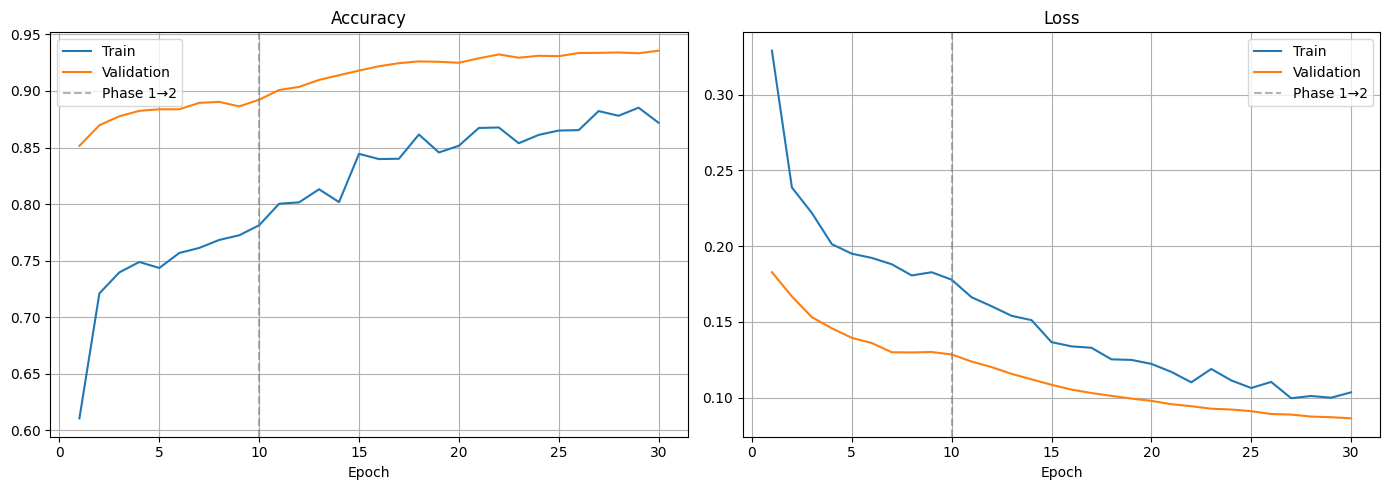

In [25]:
def plot_combined_history(h1, h2, phase_boundary=10):
    acc   = (h1.history["accuracy"]     if h1 else []) + h2.history["accuracy"]
    vacc  = (h1.history["val_accuracy"] if h1 else []) + h2.history["val_accuracy"]
    loss  = (h1.history["loss"]         if h1 else []) + h2.history["loss"]
    vloss = (h1.history["val_loss"]     if h1 else []) + h2.history["val_loss"]
    ep    = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, acc,  label="Train")
    ax1.plot(ep, vacc, label="Validation")
    ax1.axvline(x=phase_boundary, color="gray", linestyle="--",
                alpha=0.6, label="Phase 1→2")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch")
    ax1.legend(); ax1.grid(True)

    ax2.plot(ep, loss,  label="Train")
    ax2.plot(ep, vloss, label="Validation")
    ax2.axvline(x=phase_boundary, color="gray", linestyle="--",
                alpha=0.6, label="Phase 1→2")
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch")
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()

plot_combined_history(history1, history2, phase_boundary=PHASE1_EPOCHS)


In [26]:
def tta_predict(model, val_df, n_tta=5):
    """
    Run n_tta forward passes per image with random augmentations.
    Average the probability vectors. Return final class predictions.
    """
    tta_datagen = ImageDataGenerator(
        horizontal_flip=True,
        zoom_range=0.1,
        rotation_range=10,
        brightness_range=[0.85, 1.15]
    )

    all_probs = []
    for i in range(n_tta):
        tta_gen = tta_datagen.flow_from_dataframe(
            dataframe  = val_df,
            x_col      = "image_path",
            y_col      = "label",
            target_size= (224, 224),
            batch_size = 64,
            class_mode = "categorical",
            shuffle    = False
        )
        probs = model.predict(tta_gen, verbose=0)
        all_probs.append(probs)

    avg_probs = np.mean(all_probs, axis=0)
    tta_preds = np.argmax(avg_probs, axis=1)
    return tta_preds, avg_probs

print("🔄 Running TTA (5 passes) on validation set...")
tta_preds, tta_probs = tta_predict(model, val_df, n_tta=5)

tta_acc = accuracy_score(val_generator.classes, tta_preds)
std_acc = model.evaluate(val_generator, verbose=0)[1]

print(f"\nStandard prediction accuracy : {std_acc:.4f}")
print(f"TTA (5 passes) accuracy      : {tta_acc:.4f}")
print(f"TTA gain                     : +{(tta_acc - std_acc)*100:.2f}%")


🔄 Running TTA (5 passes) on validation set...
Found 5810 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 5810 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 5810 validated image filenames belonging to 36 classes.


...

Found 5810 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 5810 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Standard prediction accuracy : 0.9356
TTA (5 passes) accuracy      : 0.9368
TTA gain                     : +0.12%


In [ ]:
# ==============================
# ✅ FIX 3: Temperature Scaling — post-training calibration
# Reference: Guo et al., "On Calibration of Modern Neural Networks", ICML 2017
# ==============================

def find_optimal_temperature(model, val_generator, T_range=None):
    """
    Grid-search for the temperature T that minimises NLL on validation set.
    Returns optimal T.  T > 1 → softer probs.
    """
    if T_range is None:
        T_range = np.linspace(0.5, 5.0, 45)

    print("🔄 Extracting logits for calibration...")
    # Get raw logits before softmax
    logit_model = tf.keras.Model(
        inputs  = model.input,
        outputs = model.layers[-1].output   # softmax output
    )
    probs  = logit_model.predict(val_generator, verbose=0)
    # Convert probs back to logits
    probs  = np.clip(probs, 1e-7, 1.0)
    logits = np.log(probs)

    labels = val_generator.classes
    lb     = LabelBinarizer()
    y_bin  = lb.fit_transform(labels)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])

    best_T, best_nll = 1.0, float("inf")
    for T in T_range:
        scaled = tf.nn.softmax(logits / T).numpy()
        scaled = np.clip(scaled, 1e-7, 1.0)
        nll    = -np.mean(np.sum(y_bin * np.log(scaled), axis=1))
        if nll < best_nll:
            best_nll, best_T = nll, T

    print(f"✅ Optimal temperature: T = {best_T:.3f}  (NLL = {best_nll:.4f})")
    return best_T


def calibrated_predict(model, generator, temperature):
    """Apply temperature scaling to model predictions."""
    probs  = model.predict(generator, verbose=0)
    probs  = np.clip(probs, 1e-7, 1.0)
    logits = np.log(probs)
    return tf.nn.softmax(logits / temperature).numpy()


optimal_T = find_optimal_temperature(model, val_generator)
cal_probs = calibrated_predict(model, val_generator, optimal_T)
cal_preds = np.argmax(cal_probs, axis=1)
cal_acc   = accuracy_score(val_generator.classes, cal_preds)

print(f"Calibrated accuracy: {cal_acc:.4f}  (T={optimal_T:.3f})")
print(f"Max confidence before calibration: {np.max(model.predict(val_generator, verbose=0)):.4f}")
print(f"Max confidence after  calibration: {np.max(cal_probs):.4f}")


🔄 Extracting logits for calibration...
✅ Optimal temperature: T = 0.807  (NLL = 0.2411)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
# ── Extract features from the trained model ──────────────────
extract_datagen = ImageDataGenerator()   # no rescale — model handles it

train_extract_gen = extract_datagen.flow_from_dataframe(
    dataframe  = train_df,
    x_col      = "image_path", y_col="label",
    target_size= (224, 224), batch_size=64,
    class_mode = "categorical", shuffle=False   # CRITICAL: False for alignment
)

val_extract_gen = extract_datagen.flow_from_dataframe(
    dataframe  = val_df,
    x_col      = "image_path", y_col="label",
    target_size= (224, 224), batch_size=64,
    class_mode = "categorical", shuffle=False
)

print("🔄 Extracting features...")
train_features_raw = feature_extractor.predict(train_extract_gen, verbose=1)
val_features_raw   = feature_extractor.predict(val_extract_gen,   verbose=1)

train_labels_idx   = train_extract_gen.classes
val_labels_idx     = val_extract_gen.classes

assert len(train_features_raw) == len(train_labels_idx)
assert len(val_features_raw)   == len(val_labels_idx)

print(f"✅ Train: {train_features_raw.shape}  Val: {val_features_raw.shape}")

# Normalise features for ELM (ELM uses Euclidean distance)
scaler            = StandardScaler()
train_feat_scaled = scaler.fit_transform(train_features_raw)
val_feat_scaled   = scaler.transform(val_features_raw)

print("✅ Features normalised. No SMOTE applied — Mixup already handled augmentation.")


In [ ]:
# ==============================
# ELM Ensemble on clean (non-SMOTE) features
# ==============================

class ELM:
    def __init__(self, input_dim, hidden_units):
        scale     = np.sqrt(2.0 / input_dim)
        self.W    = np.random.randn(input_dim, hidden_units) * scale
        self.b    = np.random.randn(hidden_units) * 0.1
        self.hidden_units = hidden_units
        self.input_dim    = input_dim

    def relu(self, x):
        return np.maximum(0, x)

    def fit(self, X, y, C=1e-3):
        H         = self.relu(X @ self.W + self.b)
        self.beta = np.linalg.solve(
            H.T @ H + C * np.eye(self.hidden_units), H.T @ y
        )

    def predict(self, X):
        return np.argmax(self.relu(X @ self.W + self.b) @ self.beta, axis=1)


def ensemble_predict(models, X):
    preds = np.array([m.predict(X) for m in models])
    return np.array([
        np.bincount(preds[:, i]).argmax()
        for i in range(preds.shape[1])
    ])


lb          = LabelBinarizer()
y_train_bin = lb.fit_transform(train_labels_idx)
y_val_bin   = lb.transform(val_labels_idx)

n_models     = 7
hidden_units = 2048

elms = []
print("\n🔄 Training Ensemble ELMs...")
for i in range(n_models):
    elm = ELM(input_dim=train_feat_scaled.shape[1], hidden_units=hidden_units)
    elm.fit(train_feat_scaled, y_train_bin, C=1e-3)
    tr_acc = accuracy_score(train_labels_idx, elm.predict(train_feat_scaled))
    print(f"  ELM {i+1}/{n_models} | train acc: {tr_acc:.4f}")
    elms.append(elm)

elm_val_pred = ensemble_predict(elms, val_feat_scaled)
elm_val_acc  = accuracy_score(val_labels_idx, elm_val_pred)
print(f"\n✅ ELM Validation Accuracy: {elm_val_acc:.4f}")


In [ ]:
# ── CNN predictions ───────────────────────────────────────────
print("\n🔄 Getting CNN predictions...")
cnn_val_probs = model.predict(val_generator, verbose=1)
cnn_val_pred  = np.argmax(cnn_val_probs, axis=1)
cnn_val_acc   = accuracy_score(val_labels_idx, cnn_val_pred)

print("\n" + "=" * 55)
print("CNN (EfficientNetB3 + CBAM) CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(val_labels_idx, cnn_val_pred, target_names=class_names))

print("=" * 55)
print("ELM ENSEMBLE CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(val_labels_idx, elm_val_pred, target_names=class_names))

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(val_labels_idx, elm_val_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3)
plt.title("ELM Ensemble — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_elm.png", dpi=150)
plt.show()

# ── Final comparison ──────────────────────────────────────────
comparison = pd.DataFrame({
    "Model": [
        "EfficientNetB3 + CBAM (CNN only)",
        "EfficientNetB3 + CBAM + TTA (5×)",
        "EfficientNetB3 + CBAM + Calibration (T-scaling)",
        "EfficientNetB3 + CBAM + ELM Ensemble (7×)"
    ],
    "Val Accuracy": [
        round(cnn_val_acc, 4),
        round(tta_acc,     4),
        round(cal_acc,     4),
        round(elm_val_acc, 4)
    ]
})

comparison["Val Accuracy %"] = (
    (comparison["Val Accuracy"] * 100).round(2).astype(str) + "%"
)
print("\n📊 FINAL MODEL COMPARISON")
print(comparison[["Model", "Val Accuracy %"]].to_string(index=False))


In [ ]:
BASE_DIR = "/kaggle/working/checkpoints"
os.makedirs(BASE_DIR, exist_ok=True)

# ELM ensemble
elm_payload = [
    {"W": e.W, "b": e.b, "beta": e.beta,
     "hidden_units": e.hidden_units, "input_dim": e.input_dim}
    for e in elms
]
with open(f"{BASE_DIR}/elm_ensemble.pkl", "wb") as f:
    pickle.dump(elm_payload, f)
print("✅ ELM ensemble saved")

# Scaler
joblib.dump(scaler, f"{BASE_DIR}/feature_scaler.pkl")
print("✅ Scaler saved")

# Class mapping
with open(f"{BASE_DIR}/class_indices.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)
print("✅ Class indices saved")

# Optimal temperature (for calibrated inference)
with open(f"{BASE_DIR}/calibration.json", "w") as f:
    json.dump({"temperature": float(optimal_T)}, f)
print(f"✅ Calibration temperature saved (T={optimal_T:.3f})")

shutil.make_archive("/kaggle/working/model_export", "zip", BASE_DIR)
print("✅ model_export.zip ready — download it!")
